In [1]:
import numpy as np
from scipy import sparse, io
import torch
import pickle
from core.orbital_irrep_config import OrbitalIrrepConfig
from data.snapshot import Snapshot
from data.block_matrix import BlockMatrix
from core.basis_converter import OpenMXE3NNConverter

from matplotlib import pyplot as plt

from e3nn import o3

In [2]:
def read_geometry(file_path):
    box = []
    atoms = []
    pos_frac = []
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('#'):
                continue
            parts = line.split()
            if not parts:
                continue
            if parts[0] == 'lattice_vector':
                box.append([float(x) for x in parts[1:]])
            if parts[0] == 'atom_frac':
                atoms.append(parts[-1])
                pos_frac.append([float(x) for x in parts[1:4]])
    box = torch.tensor(box, dtype=torch.float32)
    pos_frac = torch.tensor(pos_frac, dtype=torch.float32)
    pos = torch.matmul(pos_frac, box)
    return atoms, pos, box

In [3]:
atoms, pos, box = read_geometry('../../data/fhi-aims/original/basis_small/geometry.in')
print(atoms)
print(pos)
print(box)

['H', 'H', 'H', 'H', 'O', 'O']
tensor([[1.1205, 1.1205, 1.0549],
        [2.2276, 2.2276, 1.0549],
        [2.7946, 0.5535, 2.6749],
        [0.5535, 2.7946, 2.6749],
        [0.0000, 0.0000, 0.0286],
        [1.6740, 1.6740, 1.6486]])
tensor([[3.3481, 0.0000, 0.0000],
        [0.0000, 3.3481, 0.0000],
        [0.0000, 0.0000, 3.2399]])


In [4]:
import struct
import numpy as np
import scipy.sparse as sp
from scipy import io
import sys
np.set_printoptions(threshold=sys.maxsize)

def read_elsi_to_csc(filename):
    with open(filename, "rb") as mat:
        data = mat.read()
    i8 = "l"
    i4 = "i"

    # Get header
    start = 0
    end = 128
    header = struct.unpack(i8*16,data[start:end])
    # print(header)

    # Number of basis functions (matrix size)
    n_basis = header[3]

    # Total number of non-zero elements
    nnz = header[5]

    # Get column pointer
    start = end
    end = start+n_basis*8
    col_ptr = struct.unpack(i8*n_basis,data[start:end])
    col_ptr += (nnz+1,)
    col_ptr = np.array(col_ptr)

    # Get row index
    start = end
    end = start+nnz*4
    row_idx = struct.unpack(i4*nnz,data[start:end])
    row_idx = np.array(row_idx)
    # Get non-zero value
    start = end

    if header[2] == 0:
        # Real case
        end = start+nnz*8
        nnz_val = struct.unpack("d"*nnz,data[start:end])
    else:
        # Complex case
        end = start+nnz*16
        nnz_val = struct.unpack("d"*nnz*2,data[start:end])
        nnz_val_real = np.array(nnz_val[0::2])
        nnz_val_imag = np.array(nnz_val[1::2])
        nnz_val = nnz_val_real + 1j*nnz_val_imag

    nnz_val = np.array(nnz_val)

    # Change convention
    for i_val in range(nnz):
        row_idx[i_val] -= 1

    for i_col in range(n_basis+1):
        col_ptr[i_col] -= 1

    return sp.csc_matrix((nnz_val,row_idx,col_ptr),shape=(n_basis,n_basis))

In [5]:
density = read_elsi_to_csc('../../data/fhi-aims/original/basis_small/H_spin_01_kpt_000001.csc')
density.todense().shape

(48, 48)

In [6]:
def load_basis(file_path):
    orbital_counts = {}
    atom_to_atom_id = {}
    with open(file_path, 'r') as file:
        for line in file:
            if line.startswith('#'):
                continue
            parts = line.split()
            if not parts:
                continue
            if parts[0] == 'fn.':
                continue
            fn, typ, atom_id, n, l, m = parts
            fn = int(fn) - 1
            atom_id = int(atom_id) - 1
            l = int(l)
            atom = atoms[atom_id]
            if atom not in atom_to_atom_id:
                atom_to_atom_id[atom] = atom_id
            if atom_to_atom_id[atom] == atom_id:
                orbital_counts[atom, l] = orbital_counts.get((atom, l), 0) + 1
    orbital_set_counts = {}
    for (atom, l), count in orbital_counts.items():
        orbital_set_counts[(atom, l)] = count // (2*l+1)
    orbital_dict = {}
    for (atom, l), count in orbital_set_counts.items():
        if atom not in orbital_dict:
            orbital_dict[atom] = []
        orbital_dict[atom].append(f"{count}x{l}{'e' if l%2 == 0 else 'o'}")
    return OrbitalIrrepConfig.from_dict(orbital_dict)   


In [7]:
orbital_cfg = load_basis('../../data/fhi-aims/original/basis_small/basis-indices.out')
print(orbital_cfg)

OrbitalIrrepConfig(
  H: 2x0e+1x1o
  O: 3x0e+2x1o+1x2e
)


In [8]:
def load_fhiaims_snap(
    geometry_path: str,
    basis_path: str,
    hamiltonian_path: str,
    overlap_path: str,
    density_path: str,
    basis: str = "e3nn",
) -> Snapshot:
    atoms, pos, box = read_geometry(geometry_path)
    orbital_cfg = load_basis(basis_path)
    
    ham = BlockMatrix.from_dense(
        torch.tensor(read_elsi_to_csc(hamiltonian_path).todense()).to(torch.float32),
        orbital_cfg=orbital_cfg,
        atoms=atoms,
        basis="openmx"
    )
    
    ovl = BlockMatrix.from_dense(
        torch.tensor(read_elsi_to_csc(overlap_path).todense()).to(torch.float32),
        orbital_cfg=orbital_cfg,
        atoms=atoms,
        basis="openmx"
    )
    
    den = BlockMatrix.from_dense(
        torch.tensor(read_elsi_to_csc(density_path).todense()).to(torch.float32),
        orbital_cfg=orbital_cfg,
        atoms=atoms,
        basis="openmx"
    )
    if basis == "e3nn":
        converter = OpenMXE3NNConverter(orbital_cfg)
        ham = ham.to_e3nn(converter)
        ovl = ovl.to_e3nn(converter)
        den = den.to_e3nn(converter)
    
    return Snapshot(
        ham,
        ovl,
        den,
        positions=pos,
        box=box,
    )

In [9]:
def get_snap(size, kind, basis="e3nn"):
    base_path = f'../../data/fhi-aims/{kind}/basis_{size}/'
    geometry_path = base_path + 'geometry.in'
    basis_path = base_path + 'basis-indices.out'
    hamiltonian_path = base_path + 'H_spin_01_kpt_000001.csc'
    overlap_path = base_path + 'S_spin_01_kpt_000001.csc'
    density_path = base_path + 'D_spin_01_kpt_000001.csc'
    return load_fhiaims_snap(
        geometry_path,
        basis_path,
        hamiltonian_path,
        overlap_path,
        density_path,
        basis=basis
    )

In [10]:
# snap_original = get_snap("big", "original", "openmx").to_e3nn()
# snap_rotated  = get_snap("big", "rotated",  "openmx").to_e3nn()
snap_original = get_snap("big", "original", "openmx")
snap_rotated  = get_snap("big", "rotated",  "openmx")
ham_original = snap_original.hamiltonian
ham_rotated  = snap_rotated.hamiltonian

In [11]:
snap_original.hamiltonian.orbital_cfg

OrbitalIrrepConfig(
  H: 4x0e+2x1o+1x2e
  O: 4x0e+3x1o+2x2e+1x3o+1x4e
)

In [12]:
# pi/6 rotation around y axis
theta = np.pi/6
c = np.cos(theta)
s = np.sin(theta)

R = torch.tensor([
    [c, 0, s],
    [0, 1, 0],
    [-s, 0, c]
], dtype=torch.float32)

In [13]:
ds_dict_ls = {
    0: torch.eye(1, dtype=torch.float32),
    1: torch.eye(3, dtype=torch.float32),
    2: torch.diag(torch.tensor([1, -1, 1, -1, -1])),
    3: torch.diag(torch.tensor([1, 1, 1, 1, 1, -1, 1])),
    4: torch.diag(torch.tensor([1, 1, 1, 1, 1, 1, -1, 1, -1])),
}

ds_dict = {}
for elem, irreps in snap_original.hamiltonian.orbital_cfg.element_to_irreps.items():
    ds = []
    for l in irreps.ls:
        ds.append(ds_dict_ls[l])
    # diagonal stack
    ds_dict[elem] = torch.block_diag(*ds)

snap_fix_original = get_snap("big", "original", "openmx").change_basis(ds_dict)
snap_fix_rotated  = get_snap("big", "rotated",  "openmx").change_basis(ds_dict)
snap_fix_rotated_formula = snap_fix_original.rotate(R)

In [14]:
ham_fix_original = snap_fix_original.hamiltonian.to_dense()
ham_fix_rotated  = snap_fix_rotated.hamiltonian.to_dense()
ham_fix_rotated_formula = snap_fix_rotated_formula.hamiltonian.to_dense()

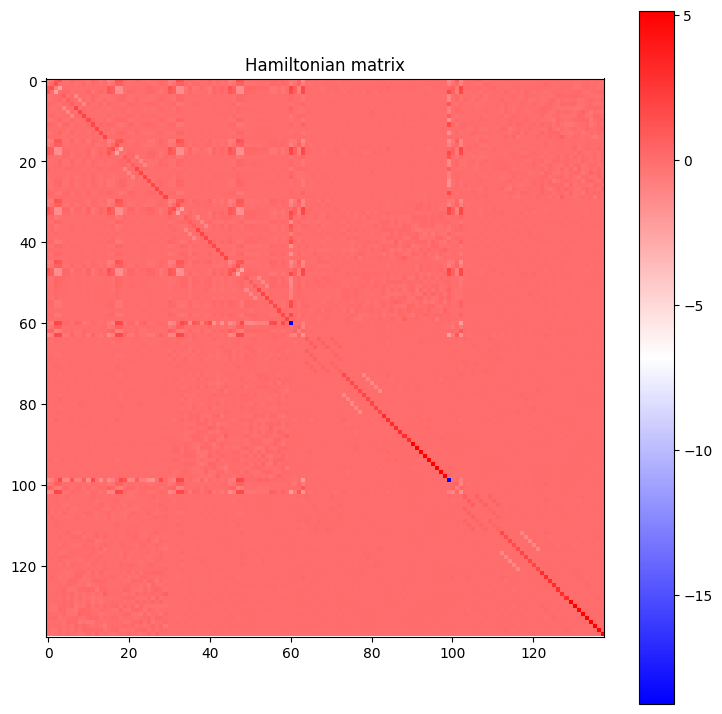

In [18]:
plt.figure(figsize=(9, 9))
plt.title("Hamiltonian matrix")
plt.imshow(ham_fix_original, cmap='bwr')
plt.colorbar()

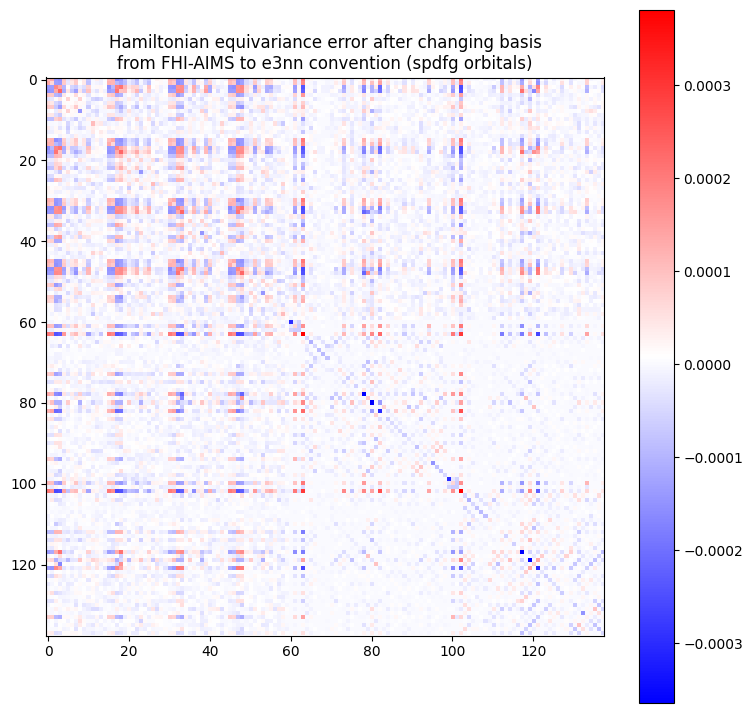

In [19]:
diff = (ham_fix_rotated-ham_fix_rotated_formula)

plt.figure(figsize=(9, 9))
plt.title(
    "Hamiltonian equivariance error after changing basis\nfrom FHI-AIMS to e3nn convention (spdfg orbitals)")
plt.imshow(diff, cmap='bwr')
plt.colorbar()